### Parkinson

##### Universidad Autónoma de Guadalajara
Aprendizaje Automatizado para la Gestión de Datos Masivos   

Profesor: Paulo López Meyer. 

Estudiante: Anayansi Cristina Hernández Abrego. 

Código vistos en clase ( Evaluación 02). 

In [27]:
## Importar las bibliotecas a utilizar 
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Herramientas de evaluación y preparación
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix

# Importación de los 4 modelos del flujo
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.svm import SVC
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier

# Configuración estética para las gráficas
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

# Cargar el archivo 
df = pd.read_csv('parkinsons_disease_data.csv')

#División de características (X) y etiquetas (Y)
# X contiene desde la columna 'Age' hasta 'Constipation' 
X = df.loc[:, 'Age':'Constipation']
# Y contiene la variable respuesta Diagnosis
y = df['Diagnosis']

# Nombres de las columnas para las etiquetas de las gráficas
feature_cols = X.columns.tolist()

# Dividir los datos en conjuntos de entrenamiento (Train) y prueba (Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=26)

# Escalamiento de los datos
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [12]:
# Análisis exploratorio 
df.head()
df.describe()
df.info()
df.columns
df.Diagnosis.value_counts() 

<class 'pandas.DataFrame'>
RangeIndex: 2105 entries, 0 to 2104
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   PatientID                 2105 non-null   int64  
 1   Age                       2105 non-null   int64  
 2   Gender                    2105 non-null   int64  
 3   Ethnicity                 2105 non-null   int64  
 4   EducationLevel            2105 non-null   int64  
 5   BMI                       2105 non-null   float64
 6   Smoking                   2105 non-null   int64  
 7   AlcoholConsumption        2105 non-null   float64
 8   PhysicalActivity          2105 non-null   float64
 9   DietQuality               2105 non-null   float64
 10  SleepQuality              2105 non-null   float64
 11  FamilyHistoryParkinsons   2105 non-null   int64  
 12  TraumaticBrainInjury      2105 non-null   int64  
 13  Hypertension              2105 non-null   int64  
 14  Diabetes           

Diagnosis
1    1304
0     801
Name: count, dtype: int64

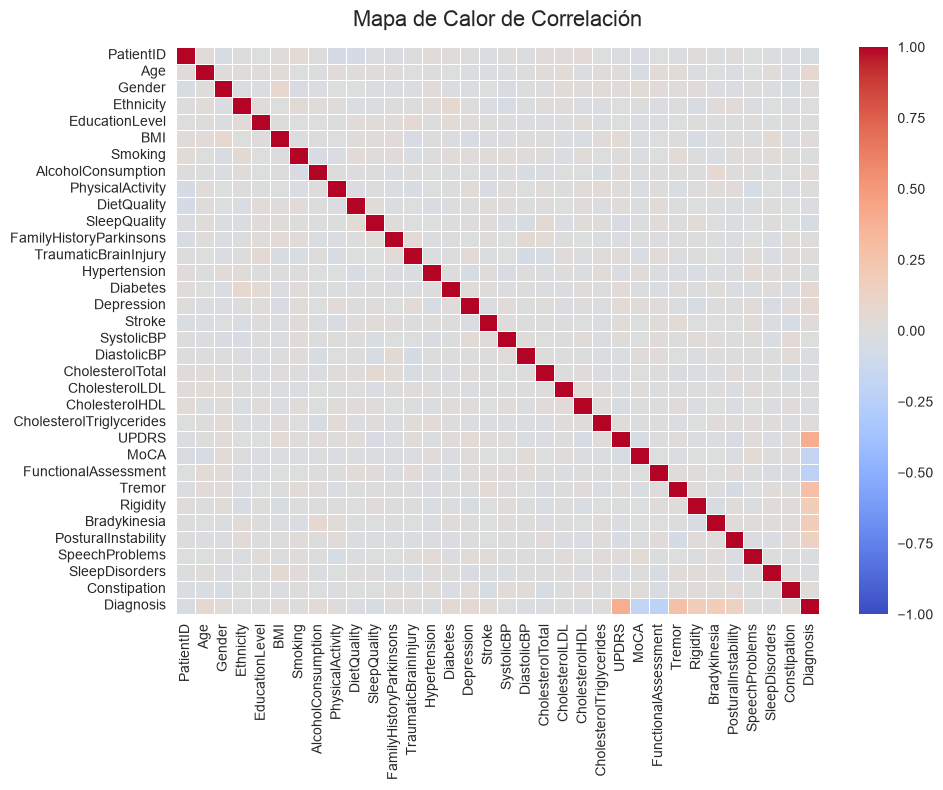

In [26]:
# Correlación

#df = df.drop(columns=['PatientID'])
df_numerico = df.select_dtypes(include=['number'])

#Calcular la matriz de correlación de Pearson
matriz_correlacion = df_numerico.corr()

plt.figure(figsize=(10, 8))

# mapa de calor 
sns.heatmap(
    matriz_correlacion, 
    annot=False,          # Muestra los números de correlación dentro de cada cuadro
    cmap='coolwarm',     # Escala de colores (azul=negativo, rojo=positivo)
    fmt=".2f",           # Limita los números a 2 decimales
    linewidths=0.5,      # Añade una línea de separación entre los cuadros
    vmin=-1, vmax=1      # Fija los límites de la escala de correlación
)

# Mostrar la gráfica
plt.title('Mapa de Calor de Correlación', fontsize=16, pad=15)
plt.tight_layout()
plt.show()


In [19]:
matriz_correlacion

,Age,Gender,Ethnicity,EducationLevel,BMI,Smoking,AlcoholConsumption,PhysicalActivity,DietQuality,SleepQuality,...,MoCA,FunctionalAssessment,Tremor,Rigidity,Bradykinesia,PosturalInstability,SpeechProblems,SleepDisorders,Constipation,Diagnosis
Age,1.000000,0.008675,0.020966,0.015130,0.035622,-0.007591,-0.009016,0.028100,0.012580,0.020866,...,-0.040081,0.039672,0.031264,-0.013883,-0.006975,-0.019534,-0.003485,0.019952,-0.028810,0.065344
Gender,0.008675,1.000000,-0.021080,-0.011429,0.072500,-0.038296,-0.020645,-0.002626,-0.005765,-0.014885,...,0.039508,0.032247,0.019554,0.028244,-0.021746,-0.021580,0.002235,-0.022533,-0.043462,0.016835
Ethnicity,0.020966,-0.021080,1.000000,0.029189,-0.003830,0.052649,0.021406,0.011913,-0.027598,-0.011927,...,0.007343,-0.017035,-0.010136,-0.032114,0.028381,0.032525,-0.018815,-0.002642,-0.013363,-0.005068
EducationLevel,0.015130,-0.011429,0.029189,1.000000,0.008032,-0.005192,-0.000339,-0.011574,0.026629,0.023454,...,-0.027360,-0.020562,-0.004924,0.012890,0.006020,-0.009958,0.020402,-0.012383,0.006028,0.004557
BMI,0.035622,0.072500,-0.003830,0.008032,1.000000,-0.008026,0.015542,-0.003622,0.008020,0.017669,...,-0.017810,-0.004586,0.003343,-0.042454,-0.010259,0.008835,-0.011635,0.047169,-0.020104,0.030114
Smoking,-0.007591,-0.038296,0.052649,-0.005192,-0.008026,1.000000,-0.032095,-0.031046,0.034870,0.009966,...,-0.021843,-0.004500,0.034733,0.003101,-0.024475,0.022392,0.015767,0.029112,0.008485,0.005241
AlcoholConsumption,-0.009016,-0.020645,0.021406,-0.000339,0.015542,-0.032095,1.000000,0.004530,0.007507,0.005871,...,-0.009050,0.002637,0.013162,-0.014867,0.062642,0.007900,0.001887,-0.013234,-0.001646,0.036699
PhysicalActivity,0.028100,-0.002626,0.011913,-0.011574,-0.003622,-0.031046,0.004530,1.000000,-0.017340,-0.007859,...,-0.029015,0.010416,-0.030366,0.014713,0.017127,0.030633,-0.050550,-0.006789,-0.017576,0.012940
DietQuality,0.012580,-0.005765,-0.027598,0.026629,0.008020,0.034870,0.007507,-0.017340,1.000000,0.041904,...,-0.008086,0.032041,-0.008994,-0.003330,-0.010982,-0.014747,-0.007910,0.015327,-0.007378,-0.022992
SleepQuality,0.020866,-0.014885,-0.011927,0.023454,0.017669,0.009966,0.005871,-0.007859,0.041904,1.000000,...,-0.011037,0.031218,0.002998,0.027758,-0.004400,-0.023170,-0.005128,0.013095,-0.001223,-0.043295


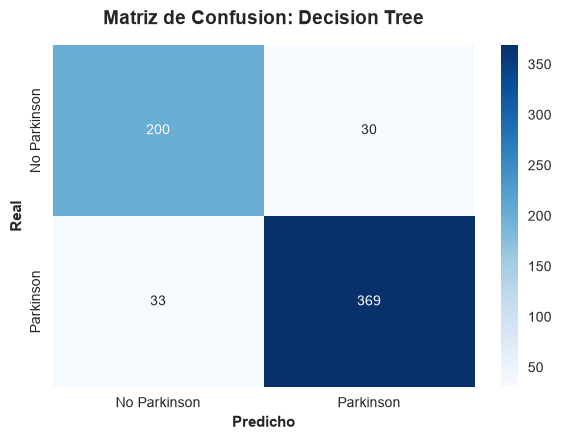

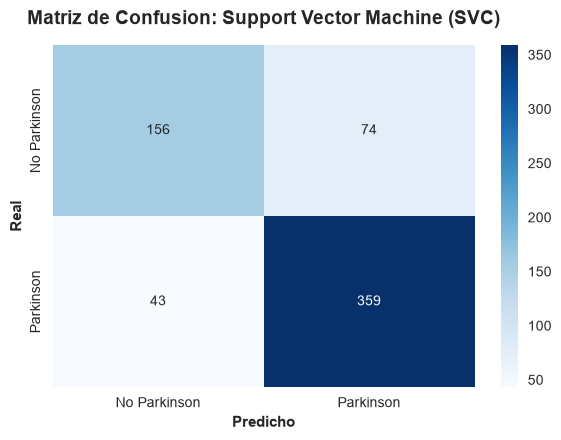

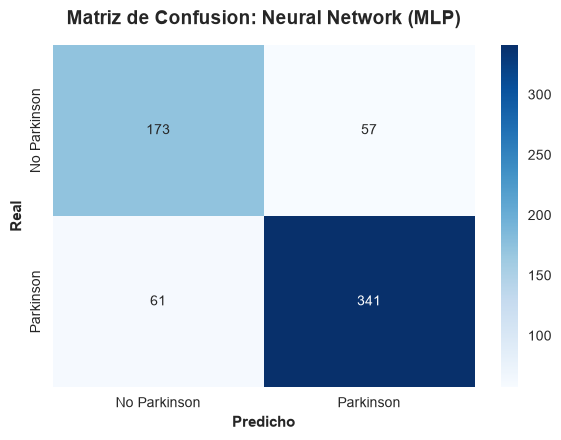

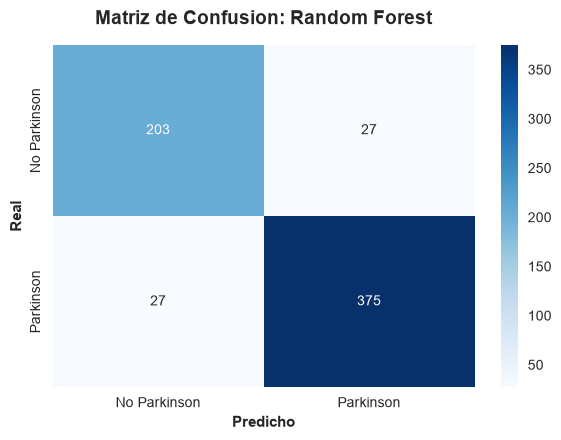


TABLA COMPARATIVA DE RENDIMIENTO DE MODELOS
                             Accuracy Precision Recall (Sensibilidad) F1-Score
Decision Tree                  90.03%    92.48%                91.79%   92.13%
Support Vector Machine (SVC)   81.49%    82.91%                89.30%   85.99%
Neural Network (MLP)           81.33%    85.68%                84.83%   85.25%
Random Forest                  91.46%    93.28%                93.28%   93.28%

Generando gráfico del Árbol de Decisión...


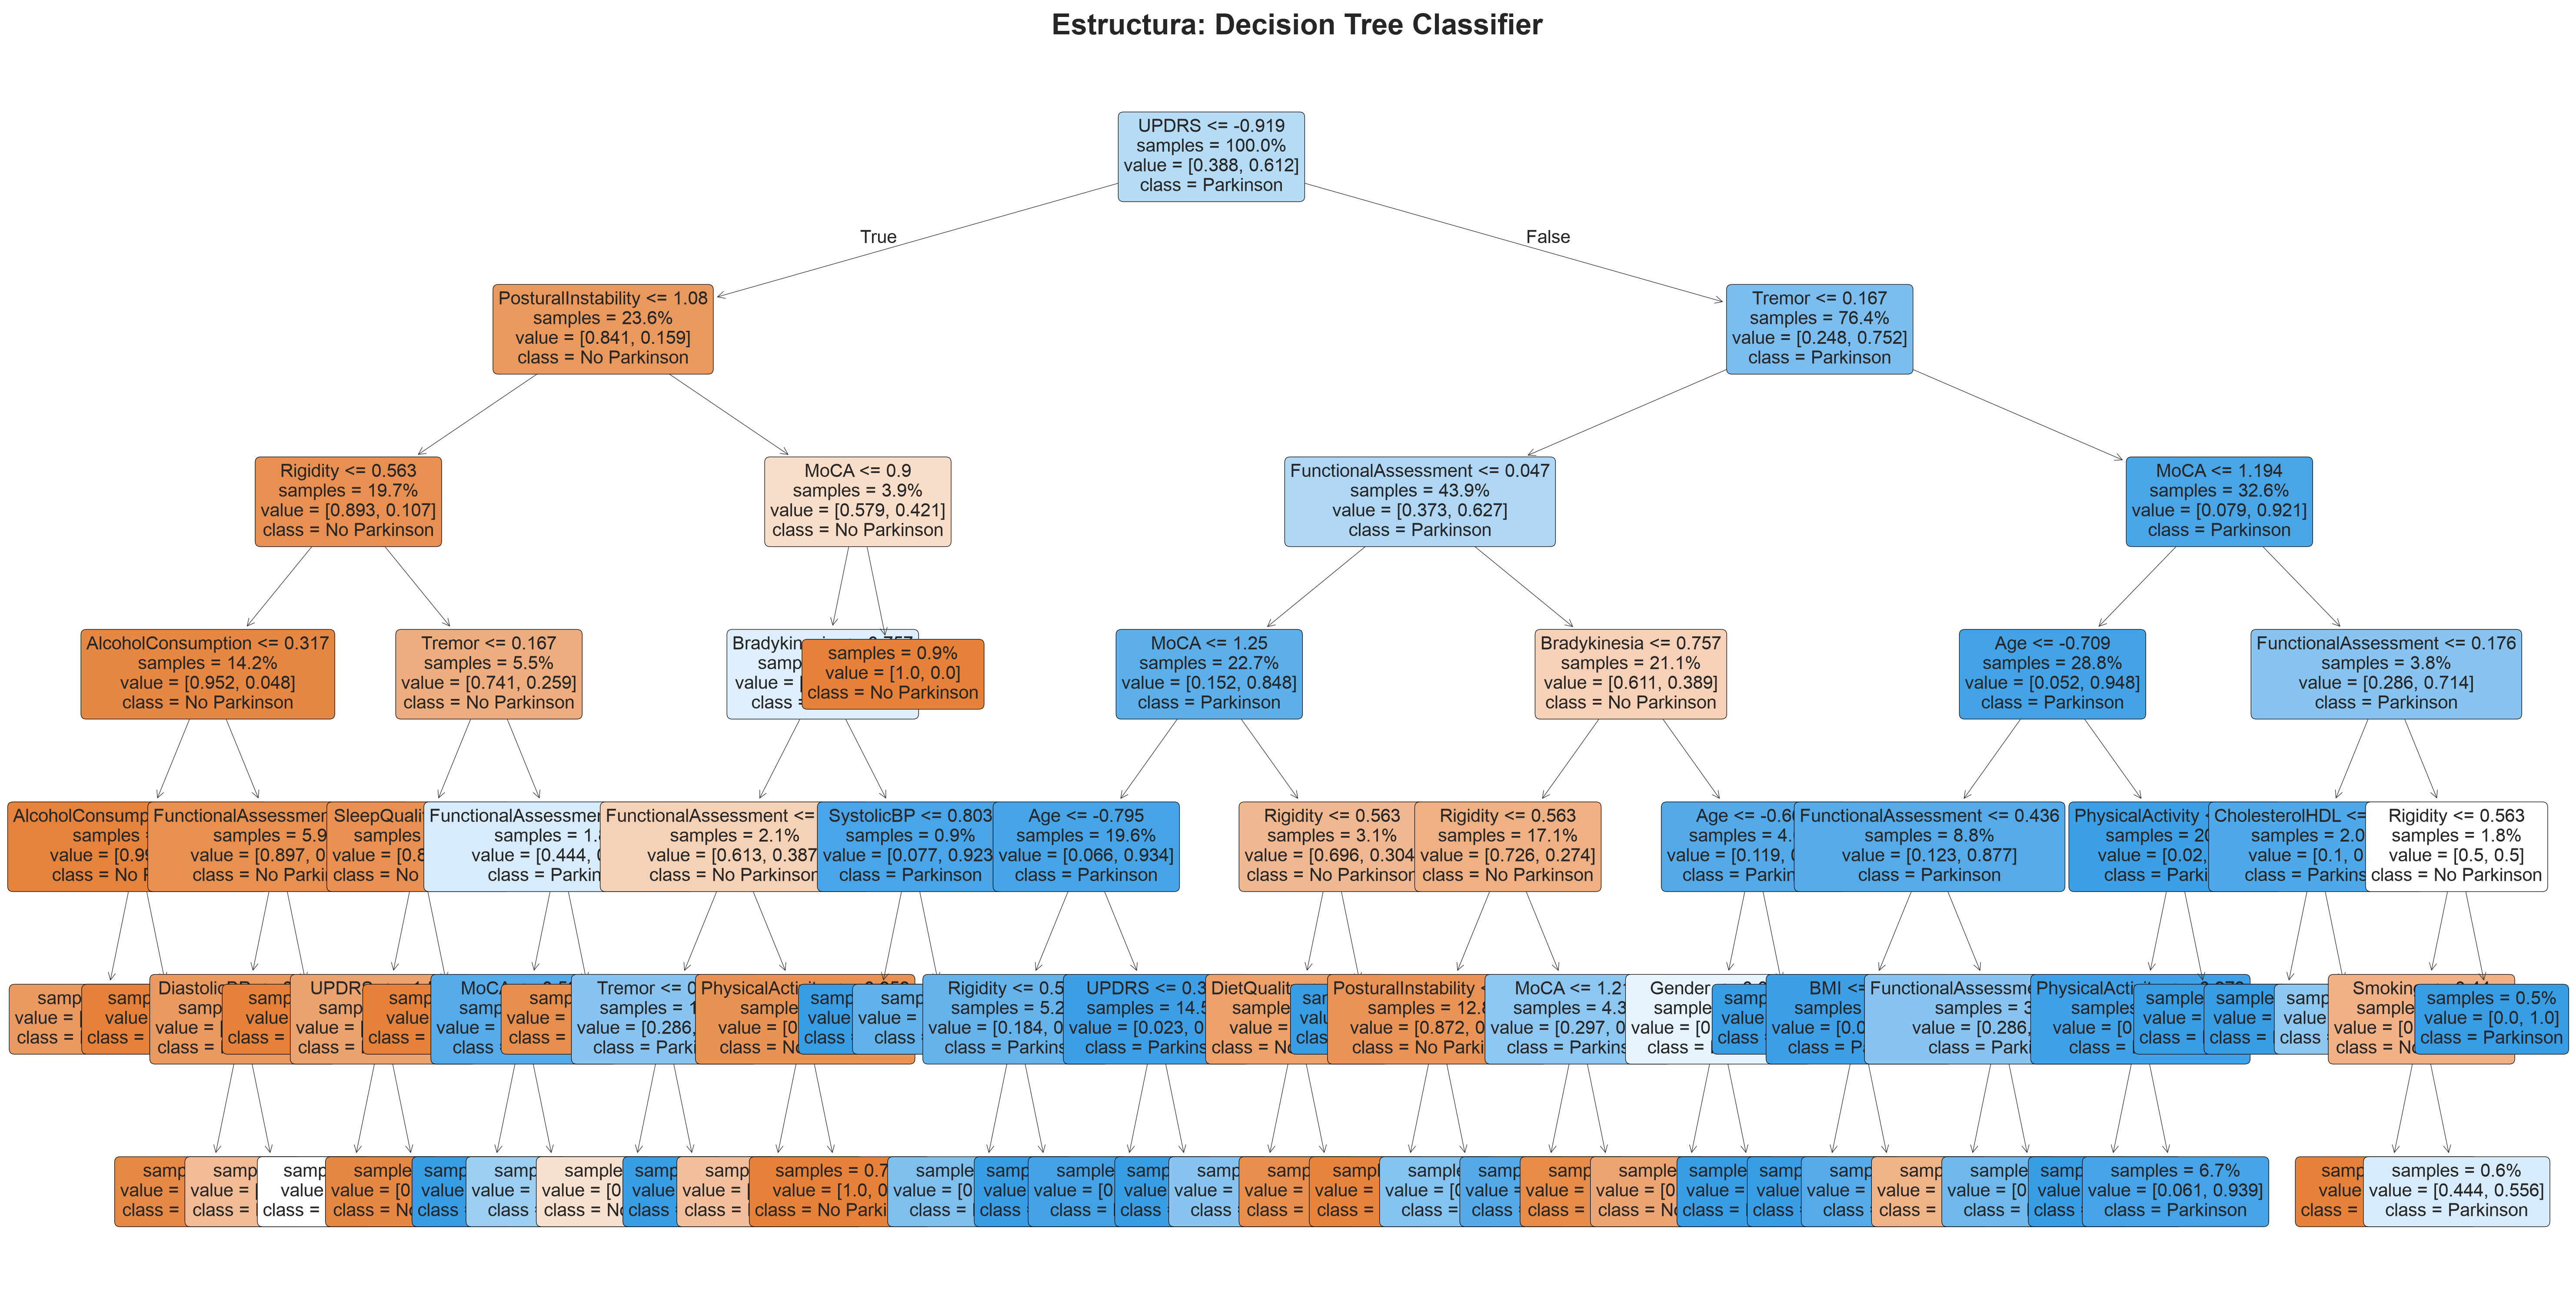


Generando gráfico de un árbol estimado de Random Forest...


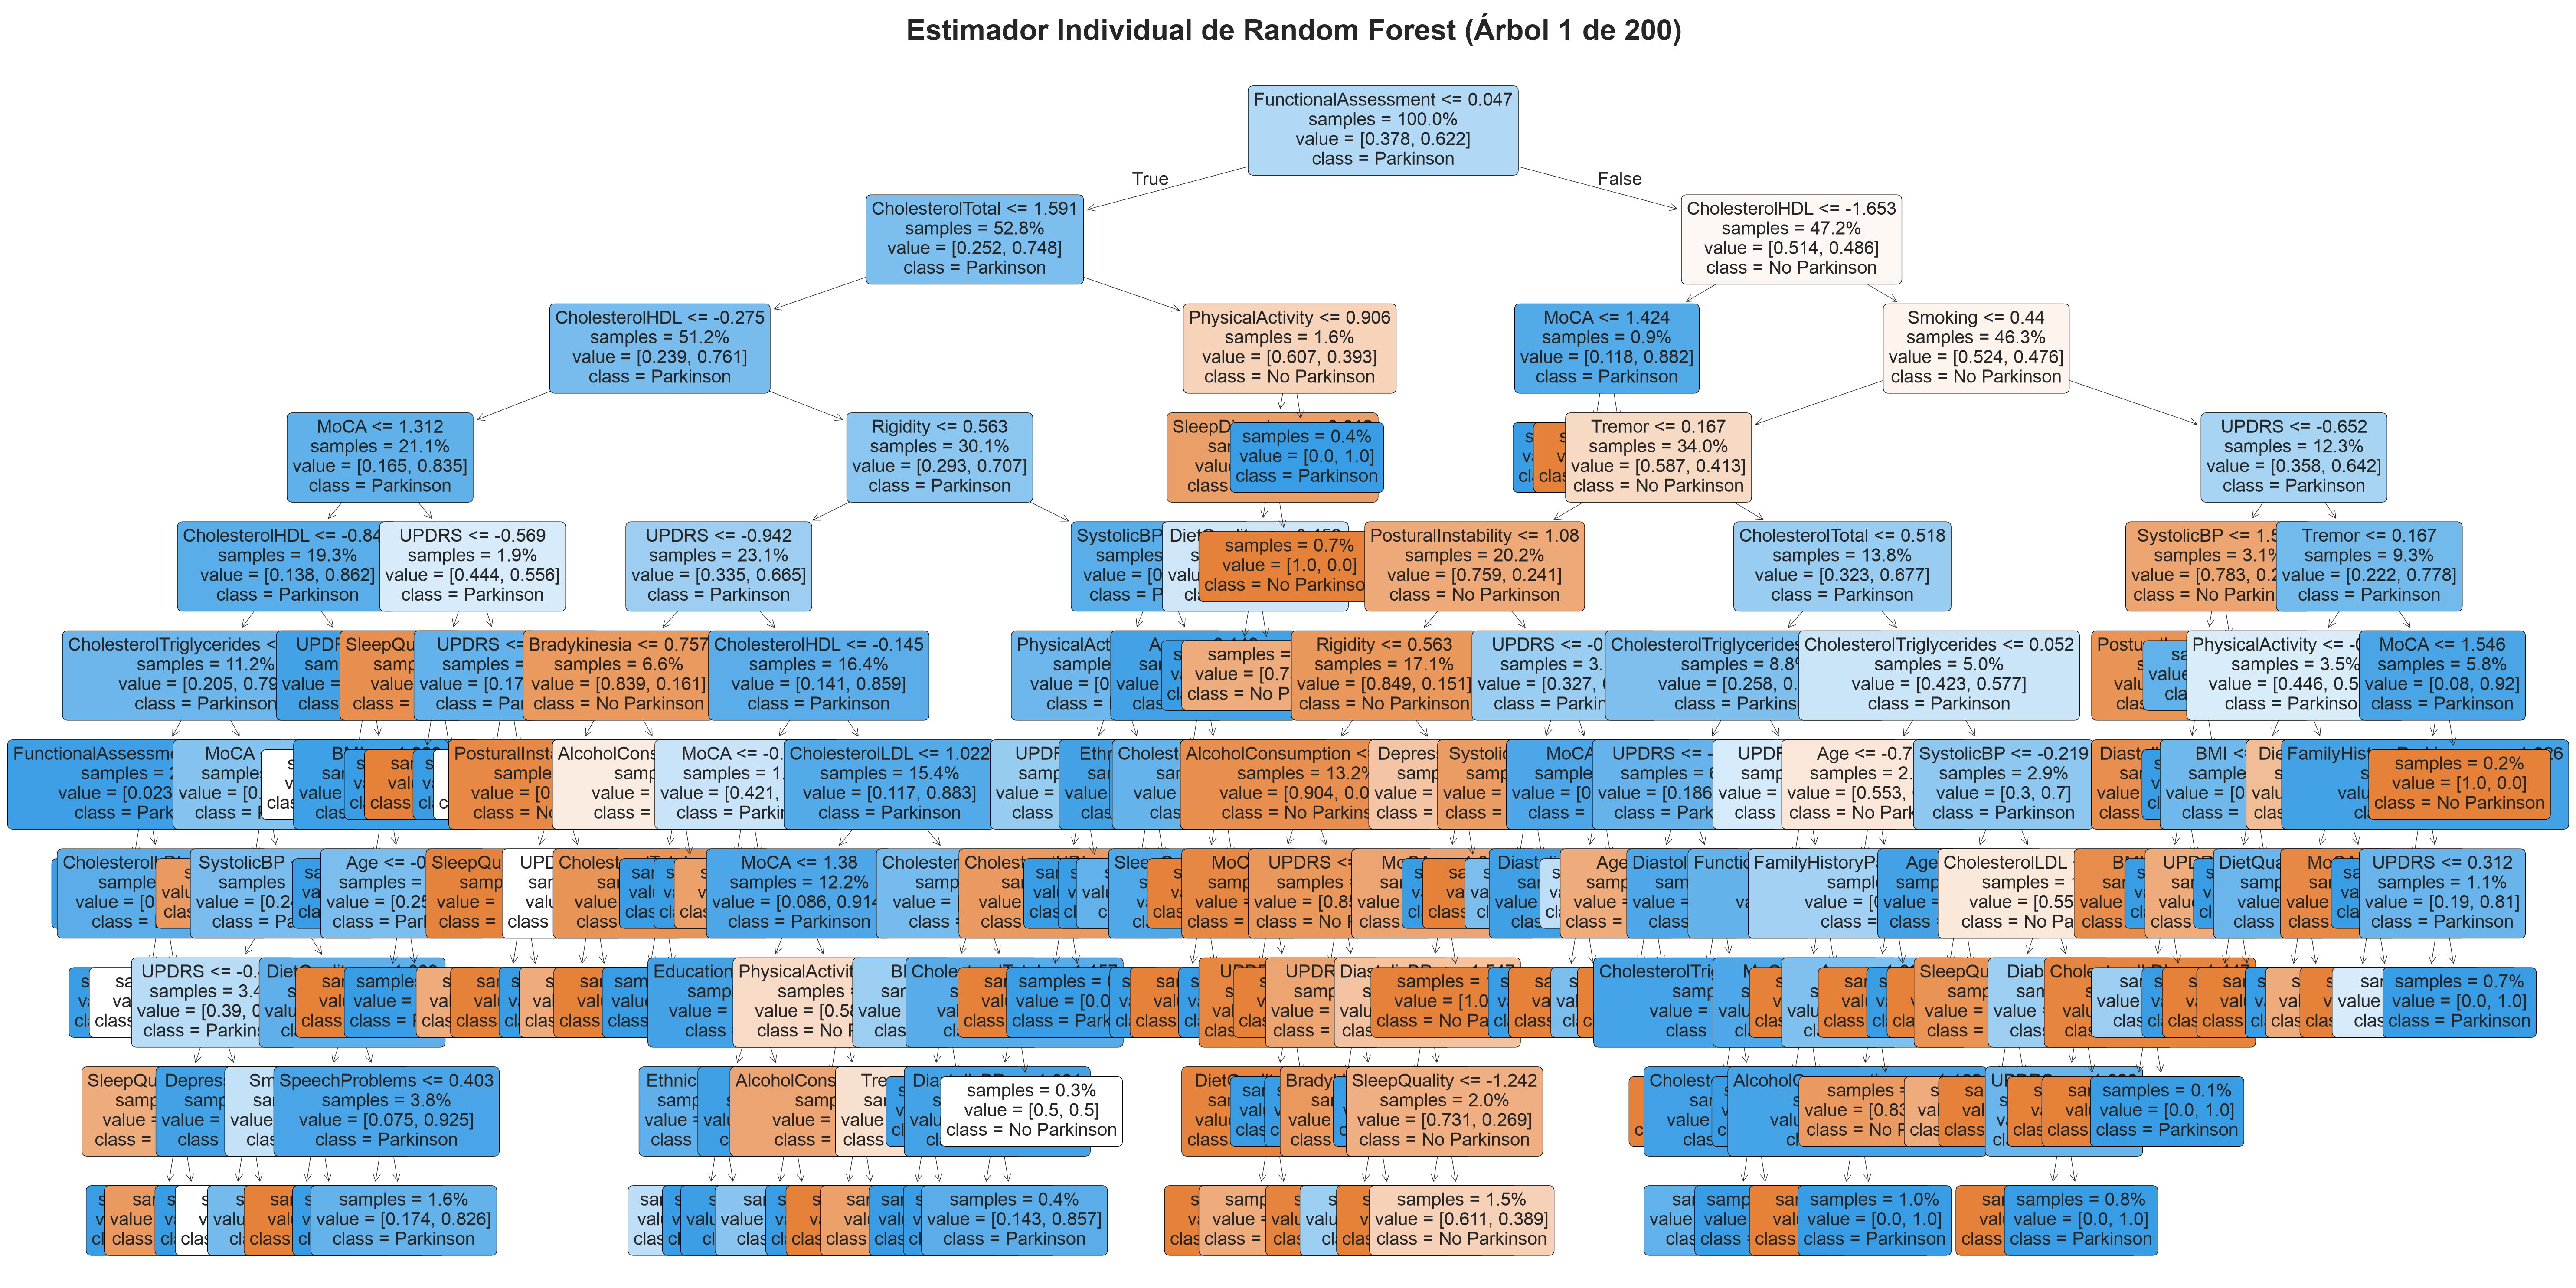

In [28]:
# Configuración de los modelos

models = {
    "Decision Tree": DecisionTreeClassifier(criterion='entropy', max_depth=6, min_samples_split= 2, min_samples_leaf = 6, random_state=26),
    "Support Vector Machine (SVC)": SVC(kernel='rbf', C=1.0, random_state=26),
    "Neural Network (MLP)": MLPClassifier(max_iter=1000, hidden_layer_sizes=(50), random_state=26, activation='relu', alpha= 0.001, learning_rate= 'adaptive'),
    "Random Forest": RandomForestClassifier(n_estimators=200, min_samples_split=5, max_depth=10, max_features= 'sqrt', random_state=26)
}
results_dict = {}

for name, model in models.items():
    # Entrenamiento
    model.fit(X_train_scaled, y_train)
    y_pred = model.predict(X_test_scaled)
    
    # Guardar métricas 
    results_dict[name] = {
        "Accuracy": accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred, zero_division=0),
        "Recall (Sensibilidad)": recall_score(y_test, y_pred, zero_division=0),
        "F1-Score": f1_score(y_test, y_pred, zero_division=0)
    }
    
    # Matriz de confusión de cada modelo
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4.5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['No Parkinson', 'Parkinson'],
                yticklabels=['No Parkinson', 'Parkinson'])
    plt.title(f'Matriz de Confusion: {name}', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Predicho', fontsize=11, fontweight='bold')
    plt.ylabel('Real', fontsize=11, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Comparación
df_comparativa_pct = pd.DataFrame(results_dict).T * 100
print("\n" + "="*75)
print("TABLA COMPARATIVA DE RENDIMIENTO DE MODELOS")
print("="*75)
print(df_comparativa_pct.to_string(formatters={
    "Accuracy": "{:,.2f}%".format, "Precision": "{:,.2f}%".format,
    "Recall (Sensibilidad)": "{:,.2f}%".format, "F1-Score": "{:,.2f}%".format
}))
print("="*75)

# Graficar el modelo "Decision Tree" estándar
print("\nGenerando gráfico del Árbol de Decisión...")
plt.figure(figsize=(20, 10), dpi=300)
plot_tree(
    models["Decision Tree"],
    feature_names=feature_cols,
    class_names=['No Parkinson', 'Parkinson'],
    filled=True, rounded=True, fontsize=10, proportion=True, impurity=False
)
plt.title("Estructura: Decision Tree Classifier", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Grafica Del primer árbol de Random Forest
print("\nGenerando gráfico de un árbol estimado de Random Forest...")
plt.figure(figsize=(20, 10), dpi=300)
un_arbol_de_rf = models["Random Forest"].estimators_[0] 
plot_tree(
    un_arbol_de_rf,
    feature_names=feature_cols,
    class_names=['No Parkinson', 'Parkinson'],
    filled=True, rounded=True, fontsize=10, proportion=True, impurity=False
)
plt.title("Estimador Individual de Random Forest (Árbol 1 de 200)", fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()
